# 19 - Experiment selection and permanent paradigm lock-in (POMDP / EFE)

**The question.** Notebook 18 (and the diagnosis notebooks 13/14) showed the honest
substrate is *monostable*: run it long enough and the evidence always wins, so paradigm
"capture" is at best a finite-horizon lag. What mechanism turns horizon lock-in into
**permanent** lock-in -- a genuine second attractor -- without cheating?

**The ontology (the thing we are modelling).** There is a true underlying world
(a hidden paradigm $\theta^*$). An *experiment* is a choice of **which distribution to
pull from** that world -- which observation likelihood $A(\cdot\mid\theta,a)$ you sample.
Crucially, **how informative an experiment is depends on what you currently believe**:
the expected information gain (EIG) of an experiment is a functional of the agent's own
posterior. An agent that is already confident *predicts* the decisive experiment's
outcome under its own paradigm, so that experiment promises it little information -- and
if experiments carry a cost, a confident agent will rationally **decline the one
experiment that could refute it.** It never pulls the refuting distribution, so it never
sees the refutation.

**Why this is the principled version.** This is pure active inference -- the expected
free energy
$$\mathrm{EFE}(a) \;=\; \underbrace{\mathbb{E}_{o}\,\mathrm{KL}[q(\theta\mid o,a)\,\|\,q(\theta)]}_{\text{epistemic (EIG)}} \;+\; \underbrace{\mathbb{E}_o\,C(o)}_{\text{pragmatic}} \;-\; \underbrace{\mathrm{cost}(a)}_{\text{effort}},\qquad
\pi(a)=\mathrm{softmax}(\gamma\,\mathrm{EFE}(a)).$$
There is **no hand-built gate**: the self-censorship falls out of the belief-dependence
of the EIG. The belief update itself stays exact Bayes (this is what lets us escape the
*martingale wall* of nb17 -- the bias is in **which data you gather**, not in how you
update on them).

**What the notebook shows.**
1. the generative model: experiments as distributions, per-experiment discriminability and cost;
2. EIG is belief-dependent $\Rightarrow$ **derived** self-censorship (confident vs uncertain vs true-believer);
3. the EFE policy: when a confident agent abandons the decisive experiment;
4. single agent: **cost $=0\Rightarrow$ monostable (truth wins)** vs **cost $>0\Rightarrow$ permanent lock-in**, with the selection-of-the-decisive-experiment trace;
5. the phase structure: lock-in over (conviction $\times$ cost) and the role of policy precision $\gamma$;
6. population with social fusion: a self-censoring bloc, and what social coupling does (and does not) add;
7. honest findings -- including that lock-in is strictly permanent only in the commitment ($\gamma\to\infty$) limit, and that **belief-utility is not required**.

**Every figure below is also saved to `notebooks/figures_nb19/*.png`** (the cell prints the path).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

from src.pomdp.gen_model import PomdpConfig, build_generative_model, build_cost
from src.pomdp.agent_pop import efe_terms, policy_posterior
from src.pomdp import step as S, observables as O

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

FIGDIR = (ROOT / 'notebooks' if (ROOT / 'notebooks').exists() else ROOT) / 'figures_nb19'
FIGDIR.mkdir(parents=True, exist_ok=True)
def save(fig, name):
    p = FIGDIR / name
    fig.savefig(p, dpi=130, bbox_inches='tight')
    print('saved figure ->', p.resolve())
    return p

# The experiment menu: x indexes experiments; higher x = sharper paradigm separation
# (Fisher info h1(x)^2/sigma^2 with h1(x)=x^3). truth = paradigm B (theta index 1).
X_GRID = (0.1, 0.5, 1.0, 2.0, 3.0)
TRUTH = 1
print('imports OK; figures ->', FIGDIR.resolve())

imports OK; figures -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19


## 1. The generative model: experiments are distributions you pull from the world

Two paradigms $\theta\in\{A,B\}$ (Newtonian $\theta{=}0$, relativistic $\theta{=}1$; the world
is $B$). An experiment $a$ (a setting $x$) yields an outcome $o\sim A_{\text{world}}(\cdot\mid\theta,a)$,
the Gaussian $\mathcal N(h_0(x)+\theta\,h_1(x),\sigma^2)$ binned into categories. The two
paradigms' outcome distributions differ more at high $x$ -- the **discriminability**
$d_a$ (symmetric KL between the columns) is the experiment's refuting power. We also
define a per-experiment **cost** $\propto d_a$ (a decisive apparatus is expensive),
normalised so the most decisive experiment has unit base cost and `cost_scale` reads in
EFE (nat) units.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19\01_generative_model.png


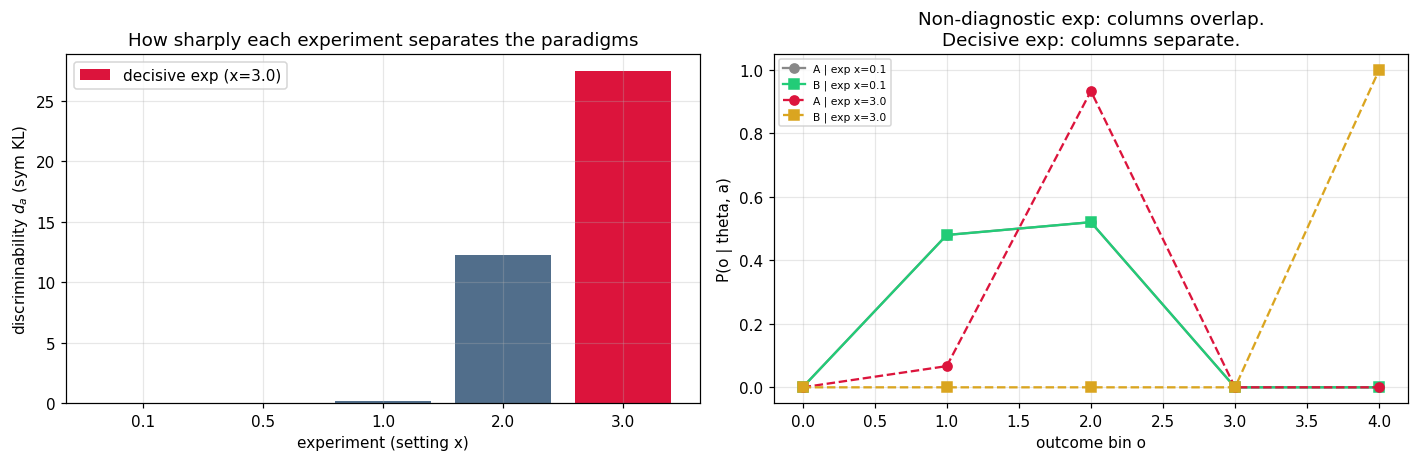

discriminability d = [0.0000e+00 5.0000e-03 2.2100e-01 1.2274e+01 2.7508e+01]  decisive experiment index = 4
cost vector at cost_scale=0.4 = [0.    0.    0.003 0.178 0.4  ]  (decisive exp -> unit base cost)


In [2]:
cfg = PomdpConfig(x_grid=X_GRID, true_paradigm=TRUTH, cost_scale=0.0)
gm = build_generative_model(cfg)
d = np.asarray(gm['d'])
a_star = O.discriminating_experiment_index(d)        # the decisive experiment
cost_demo = np.asarray(build_cost(PomdpConfig(x_grid=X_GRID, cost_scale=0.4)))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.3))
xs = np.arange(len(X_GRID))
axL.bar(xs, d, color='#357', alpha=0.85)
axL.bar(a_star, d[a_star], color='crimson', label=f'decisive exp (x={X_GRID[a_star]})')
axL.set_xticks(xs); axL.set_xticklabels([f'{x}' for x in X_GRID])
axL.set_xlabel('experiment (setting x)'); axL.set_ylabel('discriminability $d_a$ (sym KL)')
axL.set_title('How sharply each experiment separates the paradigms'); axL.legend()

# show the two outcome distributions at the least- and most-decisive experiments
A = np.asarray(gm['A_world'])     # (n_o, K, A)
for j, a in enumerate([0, a_star]):
    ax = axR
    o = np.arange(A.shape[0])
    ax.plot(o, A[:, 0, a], marker='o', ls='-' if j==0 else '--', color='#888' if a==0 else 'crimson',
            label=f'A | exp x={X_GRID[a]}')
    ax.plot(o, A[:, 1, a], marker='s', ls='-' if j==0 else '--', color='#2c7' if a==0 else 'goldenrod',
            label=f'B | exp x={X_GRID[a]}')
axR.set_xlabel('outcome bin o'); axR.set_ylabel('P(o | theta, a)')
axR.set_title('Non-diagnostic exp: columns overlap.\nDecisive exp: columns separate.')
axR.legend(fontsize=7)
plt.tight_layout(); save(fig, '01_generative_model.png'); plt.show()
print('discriminability d =', np.round(d, 3), ' decisive experiment index =', a_star)
print('cost vector at cost_scale=0.4 =', np.round(cost_demo, 3), ' (decisive exp -> unit base cost)')

## 2. The expected information gain is belief-dependent (derived self-censorship)

This is the crux. The epistemic term -- the EIG -- is a functional of the agent's current
posterior $q(\theta)$. A neutral agent expects the decisive experiment to be very
informative; a confident agent (right *or* wrong) already predicts its outcome, so the
**same experiment promises it almost no information.** We plot the EIG of the decisive
experiment as the agent's belief sweeps from confident-A to confident-B. No cost, no gate
yet -- this is purely the geometry of Bayesian surprise.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19\02_eig_belief_dependent.png


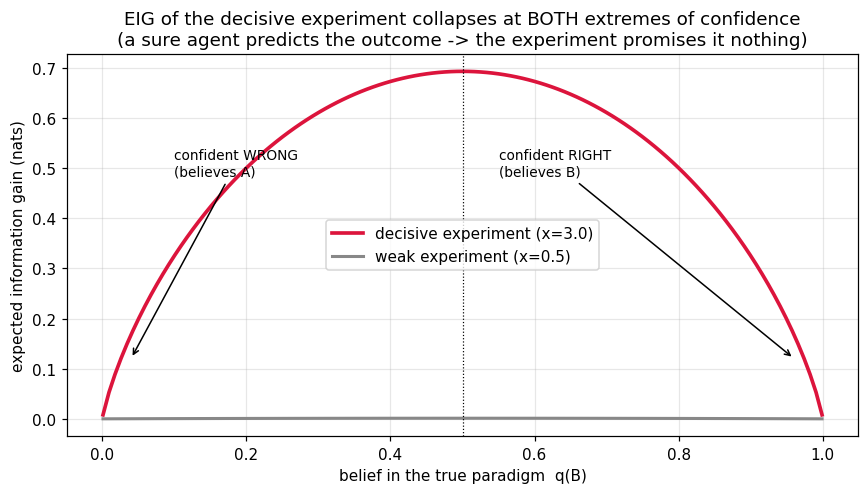

EIG(decisive): neutral q(B)=0.5 -> 0.693 nats; confident-wrong q(B)=0.02 -> 0.089 nats
A confident agent rates the refuting experiment as (almost) uninformative -- the seed of self-censorship.


In [3]:
gm0 = build_generative_model(PomdpConfig(x_grid=X_GRID, true_paradigm=TRUTH, cost_scale=0.0))
qB_axis = np.linspace(0.001, 0.999, 121)
eig_decisive, eig_cheap = [], []
for qB in qB_axis:
    q = jnp.array([1 - qB, qB])
    t = efe_terms(q, gm0['A_world'], gm0['C'], jnp.zeros(2), 0.0, cost=None)
    eig_decisive.append(float(np.asarray(t['epistemic'])[a_star]))
    eig_cheap.append(float(np.asarray(t['epistemic'])[1]))

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(qB_axis, eig_decisive, color='crimson', lw=2.4, label=f'decisive experiment (x={X_GRID[a_star]})')
ax.plot(qB_axis, eig_cheap, color='#888', lw=2, label=f'weak experiment (x={X_GRID[1]})')
ax.axvline(0.5, color='k', ls=':', lw=0.8)
ax.annotate('confident WRONG\n(believes A)', xy=(0.04, eig_decisive[3]), xytext=(0.10, max(eig_decisive)*0.7),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=9)
ax.annotate('confident RIGHT\n(believes B)', xy=(0.96, eig_decisive[-4]), xytext=(0.55, max(eig_decisive)*0.7),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=9)
ax.set_xlabel('belief in the true paradigm  q(B)'); ax.set_ylabel('expected information gain (nats)')
ax.set_title('EIG of the decisive experiment collapses at BOTH extremes of confidence\n'
             '(a sure agent predicts the outcome -> the experiment promises it nothing)')
ax.legend()
plt.tight_layout(); save(fig, '02_eig_belief_dependent.png'); plt.show()
print(f'EIG(decisive): neutral q(B)=0.5 -> {eig_decisive[60]:.3f} nats;'
      f' confident-wrong q(B)=0.02 -> {eig_decisive[2]:.3f} nats')
print('A confident agent rates the refuting experiment as (almost) uninformative -- the seed of self-censorship.')

## 3. The EFE policy: when a confident agent declines the decisive experiment

Now fold in the cost. The policy is $\pi(a)=\mathrm{softmax}(\gamma\,\mathrm{EFE}(a))$ with
$\mathrm{EFE}=\mathrm{EIG}-\mathrm{cost}$ (flat preferences). Because a confident agent's EIG on
the decisive experiment has collapsed (Section 2) but its cost has not, the decisive
experiment becomes **net-negative for confident agents only**. We plot the policy mass on
the decisive experiment vs belief, for several cost levels: confidence -- not raw cost
magnitude -- is the variable that flips the choice.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19\03_efe_policy_selfcensorship.png


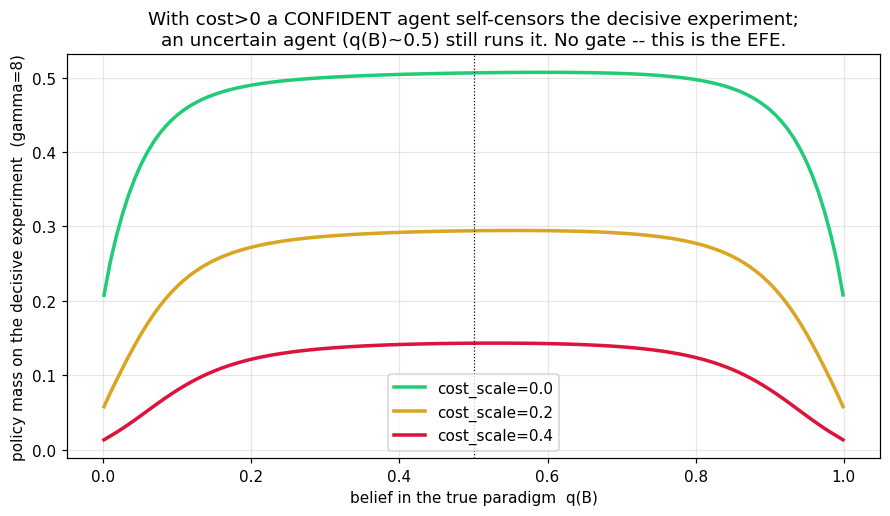

In [4]:
GAMMA = 8.0
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for cs, col in [(0.0, '#2c7'), (0.2, 'goldenrod'), (0.4, 'crimson')]:
    gmc = build_generative_model(PomdpConfig(x_grid=X_GRID, true_paradigm=TRUTH, cost_scale=cs))
    p_dec = []
    for qB in qB_axis:
        q = jnp.array([1 - qB, qB])
        q_pi, _ = policy_posterior(q, gmc['A_world'], gmc['C'], jnp.zeros(2), 0.0,
                                   GAMMA, bu_mode='plan_tilt', cost=gmc['cost'])
        p_dec.append(float(np.asarray(q_pi)[a_star]))
    ax.plot(qB_axis, p_dec, lw=2.3, color=col, label=f'cost_scale={cs}')
ax.axvline(0.5, color='k', ls=':', lw=0.8)
ax.set_xlabel('belief in the true paradigm  q(B)')
ax.set_ylabel(f'policy mass on the decisive experiment  (gamma={GAMMA:.0f})')
ax.set_title('With cost>0 a CONFIDENT agent self-censors the decisive experiment;\n'
             'an uncertain agent (q(B)~0.5) still runs it. No gate -- this is the EFE.')
ax.legend()
plt.tight_layout(); save(fig, '03_efe_policy_selfcensorship.png'); plt.show()

## 4. Single agent: cost $=0$ is monostable; cost $>0$ locks in permanently

The dynamical payoff. An isolated agent starts **confident in the wrong paradigm** ($q(B)$
small) and runs for many steps; the world is $B$. We use the commitment (greedy / argmax)
policy here -- the $\gamma\to\infty$ limit -- so the self-censored experiment is selected
with probability exactly zero (Section 6 returns to finite $\gamma$).

- **cost $=0$**: even fully committed to $A$, the agent still rates the decisive experiment
  as its best move (highest EIG), runs it, sees the refutation, and **converges to the
  truth** -- the monostable substrate of nb13/nb18.
- **cost $>0$**: past a conviction threshold the agent declines the decisive experiment
  forever, never gathers the refuting datum, and **stays permanently wrong** -- a genuine
  second attractor. The lower panel shows it stops selecting the decisive experiment.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19\04_single_agent_lockin.png


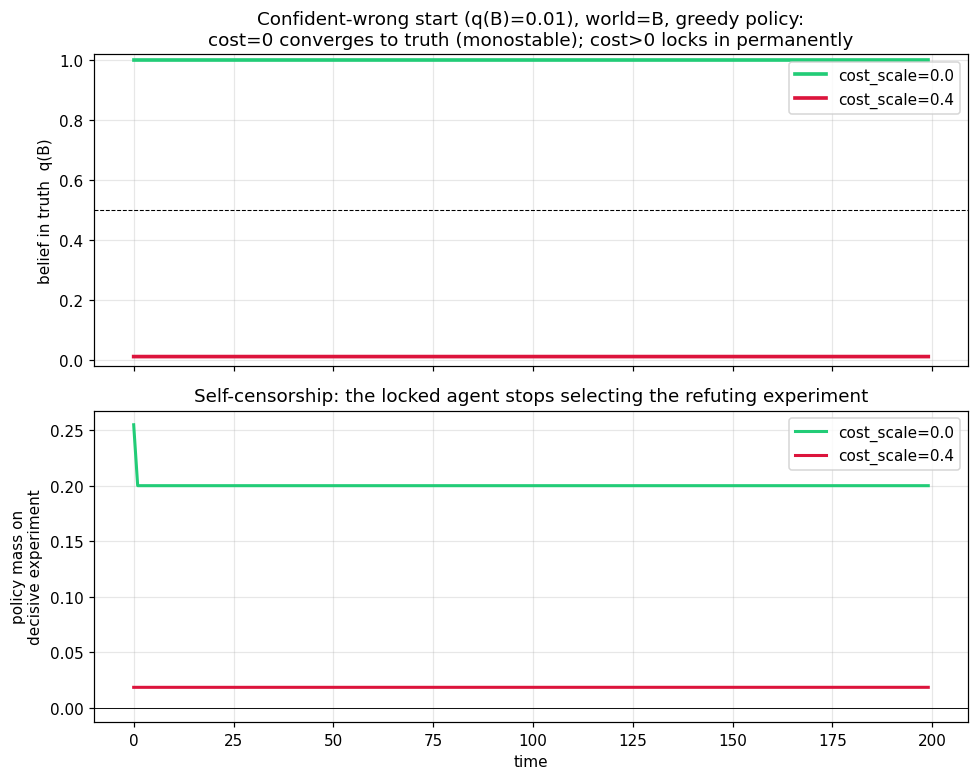

cost_scale=0.0: final q(B)=1.000  locked_wrong=False  crossed_to_truth_at=None


cost_scale=0.4: final q(B)=0.010  locked_wrong=True  crossed_to_truth_at=None


In [5]:
def single(cost_scale, qB0, n=200, greedy=True, gamma=8.0, N=24):
    # run_fast: compiled lax.scan rollout, bit-identical to the eager loop
    # (guarded by tests/test_pomdp_efe_lockin.py::test_run_fast_matches_run).
    cfg = PomdpConfig(x_grid=X_GRID, true_paradigm=TRUTH, cost_scale=cost_scale, gamma_policy=gamma)
    D = np.tile([1 - qB0, qB0], (N, 1))
    return S.run_fast(cfg, N, n, D_per_agent=D, social_mask=0.0, bu_mode='plan_tilt',
                      greedy=greedy, seed=0)

fig, (axA, axB) = plt.subplots(2, 1, figsize=(9, 7.2), sharex=True)
for cs, col in [(0.0, '#2c7'), (0.4, 'crimson')]:
    out = single(cs, qB0=0.01)
    axA.plot(out['mean_qB'], color=col, lw=2.4, label=f'cost_scale={cs}')
    axB.plot(out['p_discrim'], color=col, lw=2.0, label=f'cost_scale={cs}')
axA.axhline(0.5, color='k', ls='--', lw=0.7)
axA.set_ylabel('belief in truth  q(B)'); axA.set_ylim(-0.02, 1.02)
axA.set_title('Confident-wrong start (q(B)=0.01), world=B, greedy policy:\n'
              'cost=0 converges to truth (monostable); cost>0 locks in permanently'); axA.legend()
axB.axhline(0, color='k', lw=0.6)
axB.set_ylabel('policy mass on\ndecisive experiment'); axB.set_xlabel('time')
axB.set_title('Self-censorship: the locked agent stops selecting the refuting experiment'); axB.legend()
plt.tight_layout(); save(fig, '04_single_agent_lockin.png'); plt.show()

for cs in [0.0, 0.4]:
    s = O.lockin_summary(single(cs, 0.01), true_paradigm=TRUTH)
    print(f'cost_scale={cs}: final q(B)={s["final_belief_true"]:.3f}  '
          f'locked_wrong={s["locked_wrong"]}  crossed_to_truth_at={s["crossed_at"]}')

## 5. Phase structure: conviction $\times$ cost, and the role of policy precision $\gamma$

Where does the locked basin live? Sweep the agent's **initial conviction in the wrong
paradigm** against **cost_scale** (greedy policy) and read the final belief at $t=200$.
The locked region (red, $q(B)\!\to\!0$) needs *both* enough conviction (so the decisive
experiment's EIG has collapsed) *and* enough cost (so the collapse makes it net-negative).
The `cost_scale=0` column flips at every conviction -- the monostable substrate. The black
contour is the basin boundary -- the conviction threshold as a function of cost.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19\05a_phase_conviction_cost.png


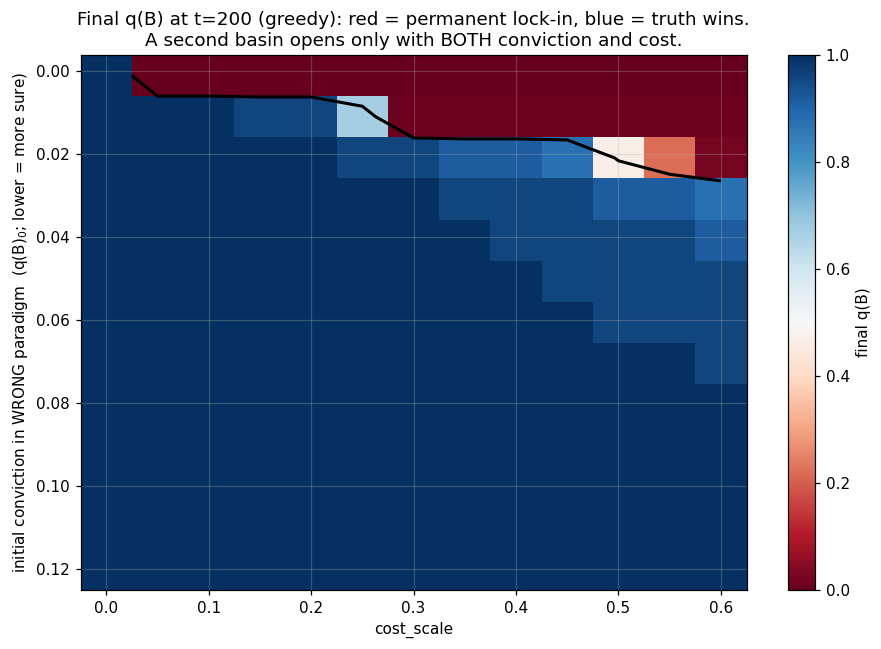

fraction of the (conviction x cost) grid that LOCKED: 13%


In [6]:
conv = np.linspace(0.001, 0.12, 13)      # initial q(B): smaller = more confident-WRONG
costs = np.linspace(0.0, 0.6, 13)
Mlock = np.zeros((len(conv), len(costs)))
for i, qB0 in enumerate(conv):
    for j, cs in enumerate(costs):
        out = single(cs, qB0=float(qB0), n=160, greedy=True)
        Mlock[i, j] = out['mean_qB'][-1]

fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.pcolormesh(costs, conv, Mlock, cmap='RdBu', vmin=0, vmax=1, shading='auto')
ax.contour(costs, conv, Mlock, levels=[0.5], colors='k', linewidths=2)
ax.set_xlabel('cost_scale'); ax.set_ylabel('initial conviction in WRONG paradigm  (q(B)$_0$; lower = more sure)')
ax.invert_yaxis()
ax.set_title('Final q(B) at t=200 (greedy): red = permanent lock-in, blue = truth wins.\n'
             'A second basin opens only with BOTH conviction and cost.')
fig.colorbar(im, ax=ax, label='final q(B)')
plt.tight_layout(); save(fig, '05a_phase_conviction_cost.png'); plt.show()
print(f'fraction of the (conviction x cost) grid that LOCKED: {(Mlock < 0.5).mean():.0%}')

**Policy precision $\gamma$ is where permanence lives.** At finite $\gamma$ the softmax keeps
a little mass on every experiment; as a confident-wrong agent's EIG shrinks on *all*
experiments the policy actually *flattens*, so the decisive experiment retains nonzero
probability and is eventually sampled -- the agent frees itself (long-horizon lock-in
only). Strictly permanent lock-in is the **commitment limit** $\gamma\to\infty$ (argmax).
We show both: sampled trajectories escape; the greedy one does not.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19\05b_gamma_permanence.png


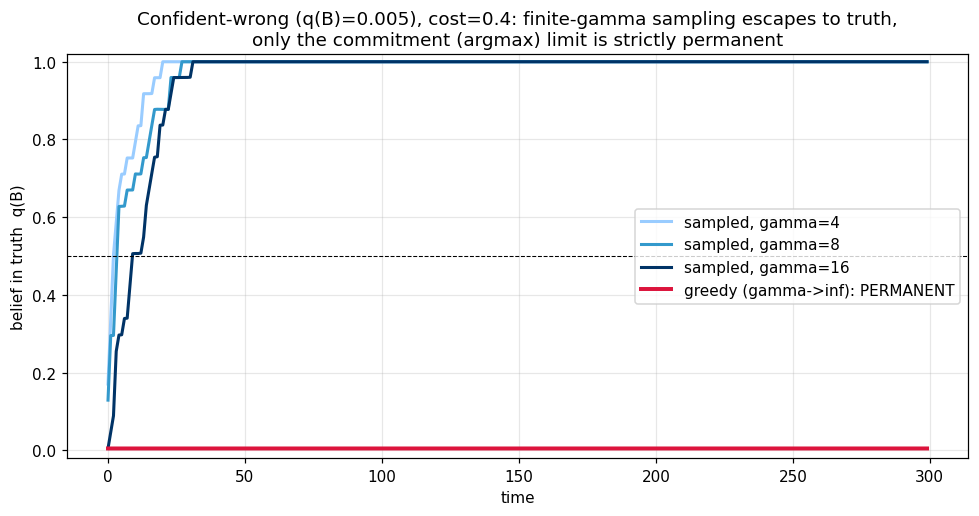

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for gamma, col in [(4.0, '#9cf'), (8.0, '#39c'), (16.0, '#036')]:
    out = single(0.4, qB0=0.005, n=300, greedy=False, gamma=gamma)
    ax.plot(out['mean_qB'], color=col, lw=2.0, label=f'sampled, gamma={gamma:.0f}')
out_g = single(0.4, qB0=0.005, n=300, greedy=True)
ax.plot(out_g['mean_qB'], color='crimson', lw=2.6, label='greedy (gamma->inf): PERMANENT')
ax.axhline(0.5, color='k', ls='--', lw=0.7)
ax.set_xlabel('time'); ax.set_ylabel('belief in truth  q(B)'); ax.set_ylim(-0.02, 1.02)
ax.set_title('Confident-wrong (q(B)=0.005), cost=0.4: finite-gamma sampling escapes to truth,\n'
             'only the commitment (argmax) limit is strictly permanent'); ax.legend()
plt.tight_layout(); save(fig, '05b_gamma_permanence.png'); plt.show()

## 6. Population: a self-censoring bloc, social fusion, and what it does (and does not) add

Finally a population on a small-world social graph, beliefs exchanged through the
trust-weighted social channel (the nb15/17 reliability mechanism). We compare three setups
at cost $>0$, greedy selection:

- **homogeneous confident-wrong** -- the whole field is past the conviction threshold;
- **entrenched minority + agnostics** -- a committed bloc plus open agnostics who *do*
  run the decisive experiment;
- the same **isolated** (no fusion), to isolate the social contribution.

The honest reading (see Section 7): a population **already past the conviction threshold**
locks in *permanently* ($q(B)\!\to\!0$), even at cost the control with cost $=0$ converges
to truth. But a self-censoring **minority does not capture the rest**: the agnostics (high
EIG) run the decisive experiment and learn the truth, so the population mean settles at the
mixture (here $\approx 0.75 = 0.75\times1 + 0.25\times0$) -- the committed quarter stays
wrong, the agnostic three-quarters get it right. Strikingly the **fused and isolated curves
coincide**: the social channel neither rescues the locked bloc nor lets it drag the
agnostics down -- it does not propagate the lock-in (the homogeneous-fusion inertia of
nb18). Capture is driven by initial conviction + commitment, not by the social coupling.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb19\06_population.png


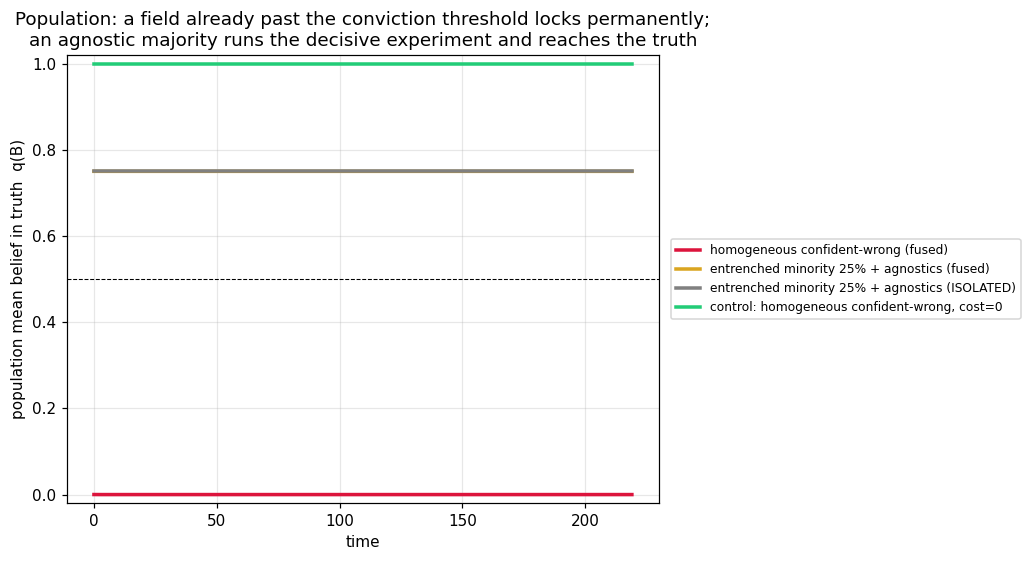

homogeneous confident-wrong (fused)             : final q(B)=0.000  locked_wrong=True
entrenched minority 25% + agnostics (fused)     : final q(B)=0.750  locked_wrong=False
entrenched minority 25% + agnostics (ISOLATED)  : final q(B)=0.750  locked_wrong=False
control: homogeneous confident-wrong, cost=0    : final q(B)=1.000  locked_wrong=False


In [8]:
def population(cost_scale, groups_q, fracs, greedy=True, social=1.0, n=220, N=60,
               gamma=8.0, qr=0.9, isolated=False):
    cfg = PomdpConfig(x_grid=X_GRID, true_paradigm=TRUTH, cost_scale=cost_scale,
                      gamma_policy=gamma, q_reliability=qr)
    counts = [int(round(f * N)) for f in fracs]; counts[-1] = N - sum(counts[:-1])
    D = np.vstack([np.tile(q, (c, 1)) for q, c in zip(groups_q, counts)])
    mask = 0.0 if isolated else social
    return S.run_fast(cfg, N, n, D_per_agent=D, social_mask=mask, bu_mode='plan_tilt',
                      greedy=greedy, seed=0)

CW = [0.999, 0.001]   # confident-WRONG: believes A; vector is [q(A), q(B)], truth=B
AG = [0.5, 0.5]       # agnostic

setups = [
    ('homogeneous confident-wrong (fused)', 'crimson',
        population(0.4, [CW], [1.0])),
    ('entrenched minority 25% + agnostics (fused)', 'goldenrod',
        population(0.4, [CW, AG], [0.25, 0.75])),
    ('entrenched minority 25% + agnostics (ISOLATED)', 'grey',
        population(0.4, [CW, AG], [0.25, 0.75], isolated=True)),
    ('control: homogeneous confident-wrong, cost=0', '#2c7',
        population(0.0, [CW], [1.0])),
]
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for label, col, out in setups:
    ax.plot(out['mean_qB'], lw=2.3, color=col, label=label)
ax.axhline(0.5, color='k', ls='--', lw=0.7)
ax.set_xlabel('time'); ax.set_ylabel('population mean belief in truth  q(B)'); ax.set_ylim(-0.02, 1.02)
ax.set_title('Population: a field already past the conviction threshold locks permanently;\n'
             'an agnostic majority runs the decisive experiment and reaches the truth')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout(); save(fig, '06_population.png'); plt.show()
for label, col, out in setups:
    s = O.lockin_summary(out, true_paradigm=TRUTH)
    print(f'{label:48s}: final q(B)={s["final_belief_true"]:.3f}  locked_wrong={s["locked_wrong"]}')

## 7. Summary -- what is principled here, and the honest limits

**The mechanism (no shortcuts).**
- An experiment is a choice of which distribution to pull from the world; its value is the
  **expected information gain**, a functional of the agent's own posterior.
- A confident agent predicts the decisive experiment's outcome, so its EIG on that
  experiment collapses (Section 2). A per-experiment **cost** then makes the
  decisive-but-low-EIG experiment net-negative -- **for confident agents only** (Section 3).
- This self-censorship is **derived from the EFE**, not imposed by a gate, and the belief
  update stays exact Bayes -- so we escape the martingale wall (the bias is in *which data
  are gathered*, not in how they are used).

**The result.**
- **cost $=0\Rightarrow$ monostable**: a confident-wrong agent still runs the decisive
  experiment and converges to the truth (reproducing nb13/nb18).
- **cost $>0\Rightarrow$ a genuine second attractor**: past a conviction threshold the
  agent self-censors the refuting experiment forever and stays permanently wrong
  (Section 4). The locked basin needs *both* conviction and cost (Section 5a).

**The honest limits (carry these into the paper).**
- Strict permanence lives in the **commitment limit** $\gamma\to\infty$ (argmax). At any
  finite $\gamma$ the policy flattens as EIG shrinks, so the decisive experiment keeps
  nonzero probability and the agent eventually escapes -- finite-$\gamma$ lock-in is
  long-horizon, not eternal (Section 5b). The bifurcation parameter is policy precision,
  which is derivable and sweepable -- not a hand-tuned gate.
- A whole population past the conviction threshold locks in **permanently** ($q(B)\to0$),
  while the cost$=0$ control converges to truth (Section 6). But social fusion **does not
  propagate** the lock-in: a self-censoring minority neither captures the agnostics nor is
  rescued by them -- the fused and isolated trajectories coincide and the population mean is
  just the mixture of the two basins. Capture is set by initial conviction + commitment,
  not by the social channel (the homogeneous-fusion inertia of nb18).
- **Belief-utility is not required.** Capture here is purely epistemic (cost + confidence);
  $U$ and $\beta_U$ are held at zero throughout. Belief-utility would be an *additional*
  symmetry-breaking field, not the engine.

All figures are saved under `notebooks/figures_nb19/`. The mechanism and these findings are
guarded by `tests/test_pomdp_efe_lockin.py`.